In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, f1_score
import pandas as pd
import numpy as np

# 1. Performance Assessment

In [32]:
df_performance = pd.read_pickle('rf_classification_mutagenicity//df_performance.pkl')

In [33]:

df_performance['MCC'] = df_performance.apply(lambda x: matthews_corrcoef(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['BACC'] = df_performance.apply(lambda x: balanced_accuracy_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['F1'] = df_performance.apply(lambda x: f1_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)

<Axes: xlabel='metric', ylabel='value'>

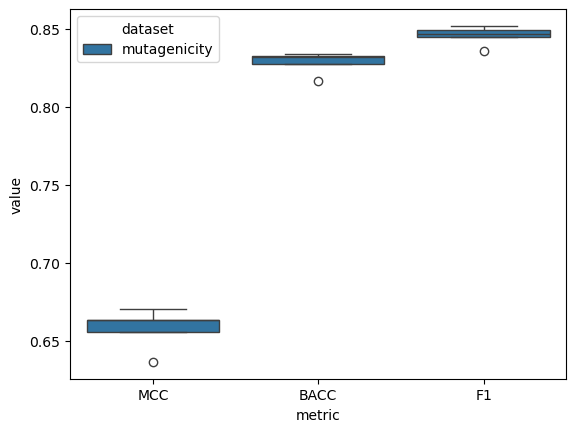

In [34]:
df_perf_molten = pd.melt(frame=df_performance,
                         id_vars=['dataset', 'split'],
                         value_vars= ['MCC', 'BACC', 'F1'],
                         value_name='value',
                         var_name='metric')
sns.boxplot(df_perf_molten,
            x='metric',
            y='value',
            hue='dataset',
)

# 2. Shapley Values

In [35]:
# get fragments of molecules as SMILES
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags

In [36]:
expl = pd.read_pickle('rf_classification_mutagenicity//df_explanation.pkl')
expl.dataset.unique()

array(['mutagenicity'], dtype=object)

In [37]:
ds = 'mutagenicity'

In [38]:
expl = expl.loc[expl.dataset == ds]

In [39]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

In [40]:
from rdkit.Chem import RWMol, SanitizeMol
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

In [41]:
def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]
    

In [42]:
expl['fragments_with_dummies_SMILES'] = expl.smiles.apply(get_BRICS_fragments_as_SMILES)
expl['fragments_without_dummies_SMILES'] = expl.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=True))

[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not removing hydrogen atom without neighbors
[16:52:21] WARNING: not r

In [43]:
r = expl.fragExplainer_result.to_list()
r_ = [list(d.values()) for d in r]
list_of_shap = [i for j in r_ for i in j]
s = expl.fragments_with_dummies_SMILES.to_list() # here use with dummies
list_of_smiles = [smiles for l in s for smiles in l]
df_frag_single = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
df_analysis = df_frag_single.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis['n_fragments'] = df_analysis['values'].apply(len)
df_analysis['mean'] = df_analysis['values'].apply(np.mean)
df_analysis['std'] = df_analysis['values'].apply(np.std)

<Axes: xlabel='value', ylabel='smiles'>

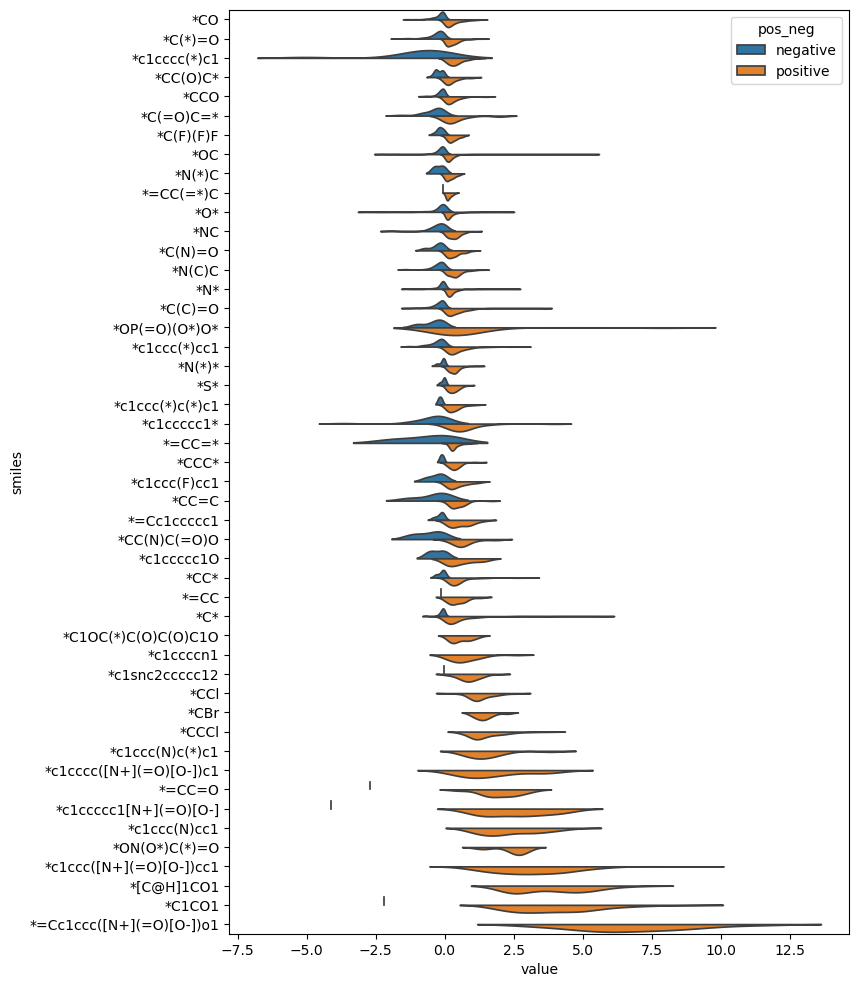

In [48]:
min_n = 25
sm_to_consider = df_analysis.loc[(df_analysis.n_fragments >= min_n) & (df_analysis['mean'] >= 0.0)].smiles.to_list() # only toxic ones

df_plot = df_frag_single.query('smiles in @sm_to_consider').copy()
df_plot['pos_neg'] = df_plot['value'].apply(lambda x: 'positive' if x >= 0 else 'negative')
mean_vals = df_analysis.loc[df_analysis.smiles.isin(sm_to_consider)]['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(sm_to_consider)[sort_idx]
fig, axs = plt.subplots(1, 1, figsize=(8, 12))
sns.violinplot(df_plot,
               x='value',
               y='smiles',
               order=sm_ordered,
               inner=None,
               density_norm='width',
               hue='pos_neg',
               split=True,
               ax=axs
               )

In [23]:
r = expl.fragExplainer_result.to_list()
r_ = [list(d.values()) for d in r]
list_of_shap = [i for j in r_ for i in j]
s = expl.fragments_without_dummies_SMILES.to_list() # here use with dummies
list_of_smiles = [smiles for l in s for smiles in l]
df_frag_single2 = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
df_analysis2 = df_frag_single2.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis2['n_fragments'] = df_analysis2['values'].apply(len)
df_analysis2['mean'] = df_analysis2['values'].apply(np.mean)
df_analysis2['std'] = df_analysis2['values'].apply(np.std)

<Axes: xlabel='value', ylabel='smiles'>

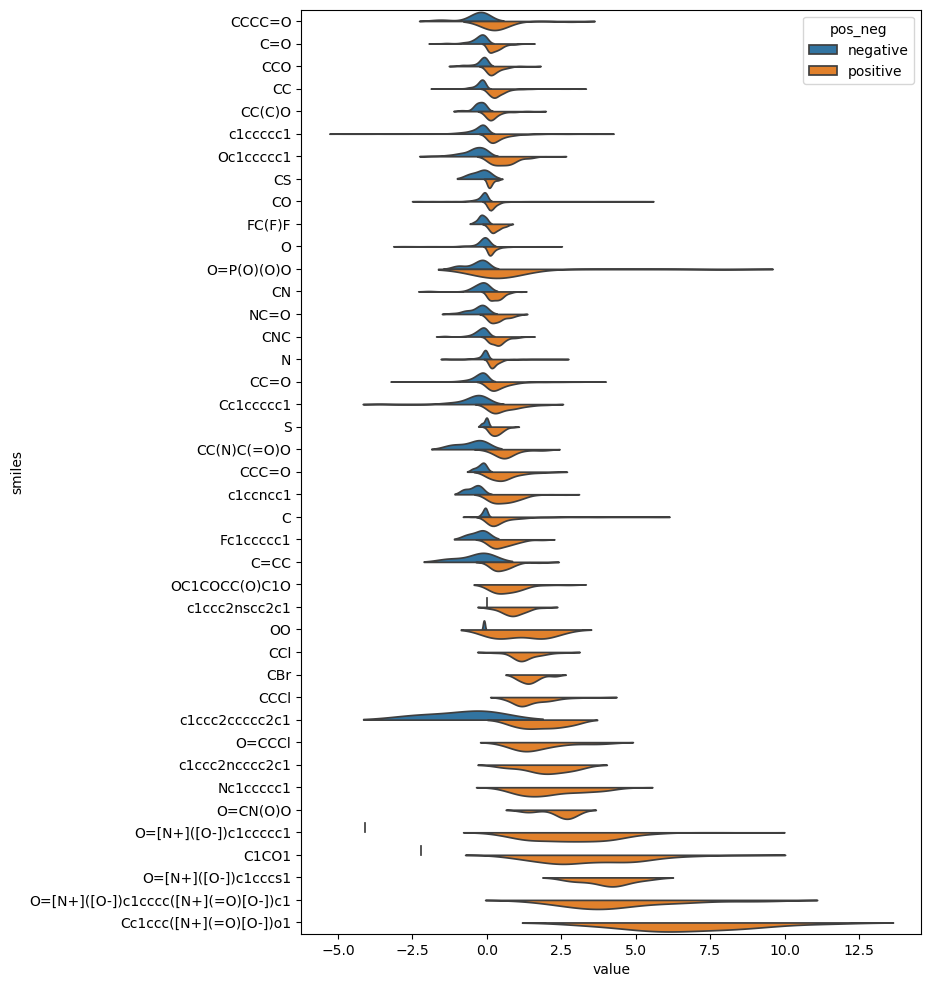

In [49]:
min_n = 25
sm_to_consider = df_analysis2.loc[(df_analysis2.n_fragments >= min_n) & (df_analysis2['mean'] >= 0.0)].smiles.to_list() # only toxic ones

df_plot = df_frag_single2.query('smiles in @sm_to_consider').copy()
df_plot['pos_neg'] = df_plot['value'].apply(lambda x: 'positive' if x >= 0 else 'negative')
mean_vals = df_analysis2.loc[df_analysis2.smiles.isin(sm_to_consider)]['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(sm_to_consider)[sort_idx]
fig, axs = plt.subplots(1, 1, figsize=(8, 12))
sns.violinplot(df_plot,
               x='value',
               y='smiles',
               order=sm_ordered,
               inner=None,
               density_norm='width',
               hue='pos_neg',
               split=True,
               ax=axs
               )